<a href="https://colab.research.google.com/github/SathyaPrakashD/ml-pipeline-fundamentals/blob/main/08_fetch_california_housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Data Loading and Initial Preparation
This section loads the California Housing dataset from local CSV files. It then processes the raw data to create a DataFrame `df` with features commonly used in the scikit-learn version of the dataset, including calculating `AveRooms`, `AveBedrms`, `AveOccup`, and scaling the `target` variable (median house value) to be in units of $100,000.

In [ ]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import os # Import os for path joining

# Step 1 — Load the dataset
# The original fetch_california_housing() call failed due to HTTP Error 403.
# We will load the dataset from the local CSV files provided in the Colab environment.

# Path to the sample data directory
sample_data_path = '/content/sample_data/'

# Load train and test datasets
df_train = pd.read_csv(os.path.join(sample_data_path, 'california_housing_train.csv'))
df_test = pd.read_csv(os.path.join(sample_data_path, 'california_housing_test.csv'))

# Concatenate them to form a single DataFrame
df_raw = pd.concat([df_train, df_test], ignore_index=True)

# Prepare the DataFrame to match the structure of fetch_california_housing
# Features as returned by fetch_california_housing:
# ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

df = pd.DataFrame()
df['MedInc']     = df_raw['median_income']
df['HouseAge']   = df_raw['housing_median_age']
df['AveRooms']   = df_raw['total_rooms'] / df_raw['households']
df['AveBedrms']  = df_raw['total_bedrooms'] / df_raw['households']
df['Population'] = df_raw['population']
df['AveOccup']   = df_raw['population'] / df_raw['households']
df['Latitude']   = df_raw['latitude']
df['Longitude']  = df_raw['longitude']

# Step 3 — Add target as number (scaled by 100,000 as per fetch_california_housing)
df['target'] = df_raw['median_house_value'] / 100000.0 # Scale target to match sklearn's output

print("Shape:", df.shape)
# For regression tasks, value_counts() on the target is not very informative as values are continuous.
# The original code's `data.target_names` is for classification, which this dataset is not.
# So, 'Classes' printout will show a long list of unique target values.
print("Classes:", df['target'].value_counts())
print("\nFirst 5 rows:")
print(df.head())

Shape: (20000, 9)
Classes: target
5.00001    939
1.37500    118
1.62500    110
1.12500     97
2.25000     90
          ... 
3.72800      1
3.04900      1
4.54400      1
4.15600      1
3.80600      1
Name: count, Length: 3824, dtype: int64

First 5 rows:
   MedInc  HouseAge   AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  1.4936      15.0  11.889831   2.718220      1015.0  2.150424     34.19   
1  1.8200      19.0  16.522678   4.105832      1129.0  2.438445     34.40   
2  1.6509      17.0   6.153846   1.487179       333.0  2.846154     33.69   
3  3.1917      14.0   6.641593   1.491150       515.0  2.278761     33.64   
4  1.9250      20.0   5.549618   1.244275       624.0  2.381679     33.57   

   Longitude  target  
0    -114.31   0.669  
1    -114.47   0.801  
2    -114.56   0.857  
3    -114.57   0.734  
4    -114.57   0.655  


### Target Variable Distribution
This cell visualizes the distribution of the `target` variable (house prices) using a histogram with a Kernel Density Estimate (KDE). It also prints the mean, median, and skewness of the target. This helps in understanding the shape of the target variable and identifying potential issues like skewness or outliers, such as the artificial cap at $500,000.

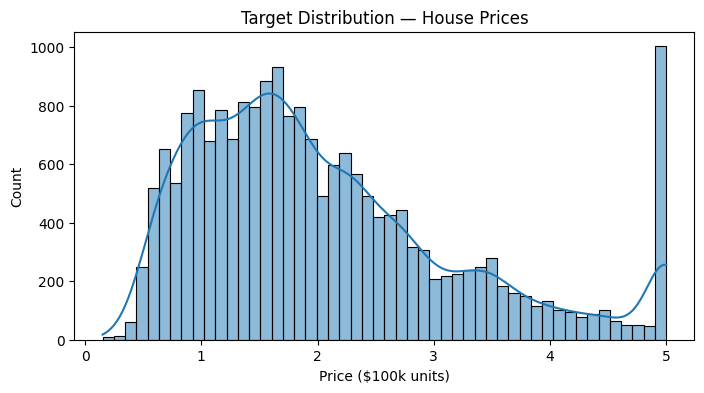

Mean   : 2.0708
Median : 1.7980
Skew   : 0.9756


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.histplot(df['target'], bins=50, kde=True)
plt.title('Target Distribution — House Prices')
plt.xlabel('Price ($100k units)')
plt.show()

print(f"Mean   : {df['target'].mean():.4f}")
print(f"Median : {df['target'].median():.4f}")
print(f"Skew   : {df['target'].skew():.4f}")

| Shape    | Mean vs Median  | Tail direction |
| :------- | :-------------- | :------------- |
| Right skew | Mean > Median   | Tail on the right |
| Left skew  | Mean < Median   | Tail on the left |
| Normal   | Mean ≈ Median   | No tail        |

In your California Housing data — Mean (2.07) > Median (1.80) — confirmed right skew.
If it were left skewed you'd see Mean < Median.

### MAE — Mean Absolute Error
Imagine you're a delivery driver. Your GPS predicts arrival times. At the end of the day your manager checks how far off each prediction was — 5 minutes early, 10 minutes late, 3 minutes early. He adds up all the differences and takes the average.
Every wrong prediction is penalised equally. Being 10 minutes late is exactly twice as bad as being 5 minutes late. Nothing more, nothing less.
That's MAE.

### RMSE — Root Mean Squared Error
Same delivery driver. Different manager. This manager squares every error before averaging — then takes the square root at the end.
What does squaring do? A 10-minute error becomes 100. A 30-minute error becomes 900.
Large errors get punished disproportionately. Being 30 minutes late isn't 3x as bad — it's 9x as bad in this manager's eyes.

### Side by side
|                | MAE                  | RMSE                           |
| :------------- | :------------------- | :----------------------------- |
| Treats errors  | Equally              | Large errors punished heavily  |
| Sensitive to outliers | No                   | Yes                            |
| When to use    | All errors equally costly | Big mistakes are unacceptable |


### RMSE is always higher than MAE — why?
Squaring any number ≥ 1 makes it bigger. So squared errors are always ≥ raw errors. That means the average of squared errors (before the root) is always inflated compared to MAE. Even after the square root, RMSE stays ≥ MAE.
The only time they're equal is when every single error is identical — no variation at all.

Relationship between MAE and RMSE
Think of the gap as a signal:

| Gap             | What it means                                 |
| :-------------- | :-------------------------------------------- |
| RMSE ≈ MAE      | Errors are consistent — no big outliers       |
| RMSE >> MAE     | Large outlier errors exist in your data       |

In your case: MAE = 0.53, RMSE = 0.74 — noticeable gap → outlier errors present. You already know why — the $500k cap.

### Do you need to calculate both?
Yes — always print both together. One without the other is incomplete. MAE tells you the average error. RMSE tells you if large errors exist. Together they give you the full picture.

### What are MAE and RMSE calculated on?
Both are calculated on the target variable — the thing you're predicting.
Specifically: the difference between actual target value and predicted target value for each row in your test set.
Error = actual house price − predicted house price
MAE and RMSE are both calculated on those errors. Not on features.

Now — MAE or RMSE as lead metric for California Housing?

### How does a metric become the "lead metric"?
Same framework you used in classification. Ask what hurts most.


**In classification you asked:**

"What is the cost of a False Positive vs False Negative?"

**In regression you ask:**

"What is the cost of a large error vs a small error?"


**Two scenarios:**

Scenario A —  Delivery time prediction

Being 2 minutes late and being 10 minutes late are both annoying but neither is catastrophic. All errors are roughly equally costly.
→ MAE is the lead metric — treats all errors equally, reflects reality accurately.

Scenario B — Bridge load prediction

A small error (5 tonnes off) is fine. A large error (50 tonnes off) could collapse the bridge.

→ RMSE is the lead metric — large errors are punished heavily, which matches the real-world consequence.

In [ ]:

# ============================================================
# CHECKPOINT 2 — Split first, then Scale (correct order)
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Step 1 — Separate features and target
X = df.drop(columns=['target'])
y = df['target']

# Step 2 — Split BEFORE scaling
# test_size=0.2 means 20% test, 80% train
# random_state fixes the random split so results are reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

# Step 3 — Fit scaler on TRAIN only
scaler = StandardScaler()
scaler.fit(X_train)             # learns mean & std from train only

# Step 4 — Transform both using train's stats
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)



# Step 5 — Verify scaling worked
X_train_df_before = pd.DataFrame(X_train, columns=X.columns)
print("\nBefore scaling (train set):")
print(X_train_df_before.head())

X_train_df = pd.DataFrame(X_train_scaled, columns=X.columns)
print("\nAFTER scaling (train set):")
print(X_train_df.head())

Train size: 16000
Test size: 4000

Before scaling (train set):
      MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
5894  4.6042      21.0  5.359524   1.076190       913.0  2.173810     33.82   
3728  3.3472      45.0  4.244726   0.970464      1237.0  5.219409     33.87   
8958  5.5925      13.0  5.757981   1.043254      3188.0  3.283213     34.30   
7671  3.5048      13.0  4.188761   1.046110      1573.0  2.266571     33.87   
5999  4.2500      44.0  4.592715   0.927152       984.0  3.258278     33.80   

      Longitude  
5894    -118.20  
3728    -117.93  
8958    -118.90  
7671    -118.37  
5999    -118.21  

AFTER scaling (train set):
     MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  0.389317 -0.605741 -0.027003  -0.043917   -0.451875 -0.180305 -0.843484   
1 -0.274318  1.302840 -0.468627  -0.257797   -0.168672  0.497751 -0.820102   
2  0.911091 -1.241934  0.130844  -0.110545    1.536662  0.066687 -0.619017   
3 -0.191113 -1

MAE, RMSE, and R².
You asked about MAE vs RMSE just now, but R² is equally important as a lead metric candidate.
Here's when each one leads:

| Metric | Lead metric when...                                           |
| :----- | :------------------------------------------------------------ |
| MAE    | All errors are roughly equally costly, or outliers shouldn't dominate |
| RMSE   | Large errors are genuinely unacceptable — bridge load, medical dosage, financial risk |
| R²     | You care about how well the model explains the data — not the size of errors |

R² as lead metric — when does it make sense?
When your stakeholder asks "how good is your model?" not "how far off are your predictions?"
Example — a research paper comparing two models on the same dataset. You don't care about the dollar error size, you care about which model explains more variance. R² is your lead metric there.

For California Housing specifically:

MAE → lead metric ✅ (your reasoning was correct)
RMSE → supporting metric (tells you outlier errors exist)
R² → supporting metric (tells you how much variance the model explains — 57.6%)

The scale is simple:

| R² value | What it means                       |
| :------- | :---------------------------------- |
| 1.0      | Model explains everything — perfect |
| 0.576    | Model explains 57.6% — moderate     |
| 0.0      | Model explains nothing — just predicting the mean every time |
| Negative | Model is worse than just predicting the mean |

### Training and Evaluating a Linear Regression Model
This section trains a `LinearRegression` model on the scaled training data and makes predictions on the scaled test data. It then evaluates the model's performance using standard regression metrics: Mean Absolute Error (MAE), Mean Squared Error (MSE), R-squared (R²), and Root Mean Squared Error (RMSE). It also shows an example of a single prediction.

In [ ]:
# ============================================================
# CHECKPOINT 3 — Train Logistic Regression
# ============================================================

from sklearn.linear_model import LinearRegression # Changed from LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score # Added for regression metrics
import numpy as np
from sklearn.metrics import mean_absolute_error

# Step 1 — Create the model
model = LinearRegression()   # Changed from LogisticRegression

# Step 2 — Train it (only on train data)
model.fit(X_train_scaled, y_train)   # Model learns patterns and relationships

# Step 3 — Predict on test set
y_pred = model.predict(X_test_scaled)   #

# Step 4 — Score it (using regression metrics)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared: {r2:.4f}")
print(f"rmse : {rmse:.4f}")


# Step 5 — Inspect one prediction
print("\nFirst test sample — true label   :", y_test.values[0])
print("First test sample — predicted    :", y_pred[0])
# For Linear Regression, there are no probabilities, only direct predictions
# print("First test sample — probabilities:", model.predict_proba(X_test_scaled)[0].round(3))

MAE: 0.5339
Mean Squared Error: 0.5326
R-squared: 0.6121
rmse : 0.7298

First test sample — true label   : 0.719
First test sample — predicted    : 0.11209678036071558


### Cross-Validation for Linear Regression
To get a more robust estimate of the model's performance and to avoid overfitting, cross-validation is performed. A `Pipeline` is used to encapsulate the `StandardScaler` and `LinearRegression` model, ensuring that scaling is applied correctly within each fold of the cross-validation. The `cross_val_score` function calculates the negative mean squared error across 5 folds, which is then converted to RMSE for interpretability. Additionally, a prediction for a custom district is made to demonstrate the pipeline's usage.

In [ ]:
# ============================================================
# CHECKPOINT 4 — Cross Validation
# ============================================================

from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import numpy as np # Import numpy for mean and std

# Step 1 — Build a pipeline (scaler + model in one object)
# This ensures scaling happens correctly inside each fold
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

# Step 2 — Fit the pipeline on the training data
pipeline.fit(X_train, y_train)

# Step 3 — Make a prediction with the fitted pipeline
import pandas as pd

custom_district = pd.DataFrame([[3.5, 30.0, 5.5, 1.0, 800.0, 2.5, 37.85, -122.25]],
    columns=['MedInc','HouseAge','AveRooms','AveBedrms',
             'Population','AveOccup','Latitude','Longitude'])

predicted_price = pipeline.predict(custom_district)[0]
print(f"Predicted house price for custom district: ${predicted_price * 100000:,.0f}")

# Step 4 — Perform cross-validation (using the pipeline for robustness)
# Using 'neg_mean_squared_error' as scoring for regression models
cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(-cv_scores) # Convert negative MSE to RMSE

print(f"\nCross-validation RMSE scores: {rmse_scores.round(4)}")
print(f"Mean CV RMSE: {rmse_scores.mean():.4f}")
print(f"Std CV RMSE: {rmse_scores.std():.4f}")

Predicted house price for custom district: $210,082

Cross-validation RMSE scores: [0.6525 0.7653 0.8453 0.7097 0.7333]
Mean CV RMSE: 0.7412
Std CV RMSE: 0.0638


In [ ]:
print(f"Raw prediction: {predicted_price}")
print(f"Predicted house price: ${predicted_price * 100000:,.0f}")

Raw prediction: 2.1008234112068958
Predicted house price: $210,082


### The full EDA sequence for regression:

| Step | What you do                                     | What it tells you                              |
| :--- | :---------------------------------------------- | :--------------------------------------------- |
| 1    | Target distribution                             | Is the target skewed? Any data quality issues? |
| 2    | Feature correlation                             | Which features drive the target? Any features too similar to each other? |
| 3    | Lead metric decision                            | Based on target distribution findings          |
| 4    | Model selection                                 | Based on correlation findings                  |

Why correlation comes before model selection:
The heatmap answers two questions that directly affect which model you choose:

Question 1 — Correlation with target
If features correlate strongly and linearly with the target → Linear Regression is a good fit.
If correlations are weak or non-linear → you need a more powerful model like Random Forest or Gradient Boosting.

Question 2 — Correlation between features (multicollinearity)
If two features are strongly correlated with each other — say AveRooms and AveBedrms — they're telling the model the same thing twice. This confuses Linear Regression specifically. You may need to drop one.

For classification, the equivalent EDA step is:

Class balance check → lead metric decision
Feature importance → model selection

### Feature Correlation Heatmap
This heatmap visualizes the correlation matrix of all features in the DataFrame, including the target. It helps identify highly correlated features (multicollinearity) and the strength and direction of relationships between features and the target variable. Strong correlations among features can impact linear models, while strong correlations with the target indicate predictive power.

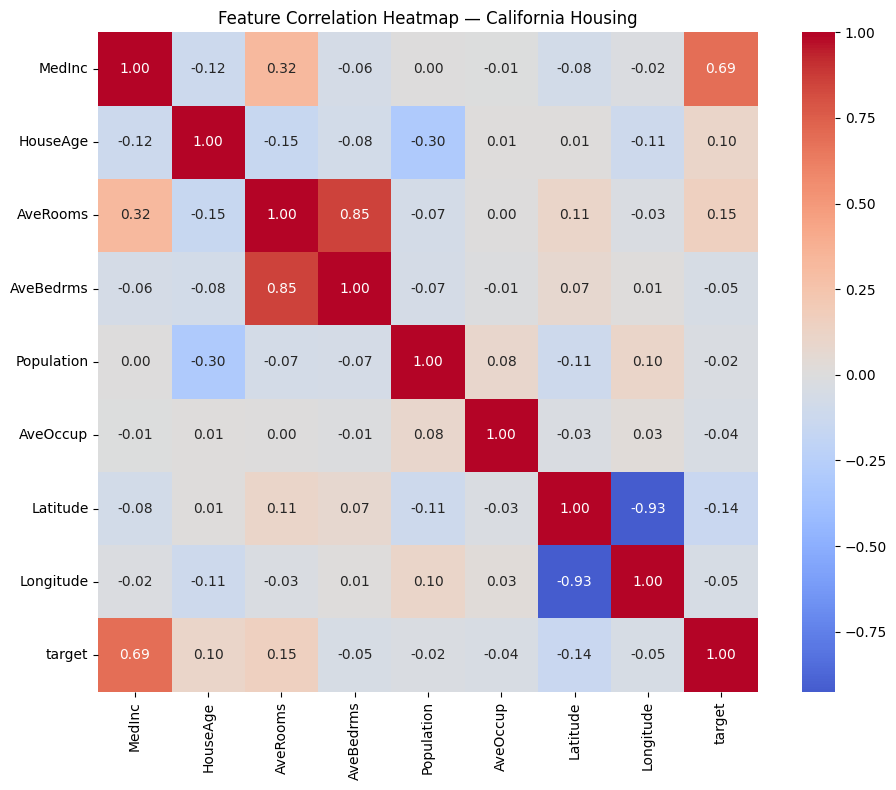

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(),
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True)
plt.title('Feature Correlation Heatmap — California Housing')
plt.tight_layout()
plt.show()

Look at the target row values precisely:

FeatureCorrelation with target

MedInc0.69 — strongest ✅

AveRooms0.15 — second

HouseAge0.10 — third

HouseAge and AveRooms are swapped in ordering.

The values are close but AveRooms (0.15) edges out HouseAge (0.10).



Two pairs of features are highly correlated with each other:

AveRooms ↔ AveBedrms (0.85)

Latitude ↔ Longitude (-0.93)


This is multicollinearity. For Linear Regression this causes confusion — the model gets conflicting signals from features saying the same thing twice.

Linear Regression assumes features contribute independently to the prediction.
Think of it like a recipe. The model says:

"Price = (weight × MedInc) + (weight × AveRooms) + (weight × AveBedrms) + ..."

When AveRooms and AveBedrms are 85% correlated — they're nearly the same ingredient added twice. The model gets confused about how much weight to give each one. The weights become unstable and unreliable.

Two ways to handle it:
OptionWhat you doWhen to useDrop one featureRemove AveBedrms, keep AveRoomsSimple fix for Linear RegressionSwitch to Random ForestTree-based models handle multicollinearity naturallyMore powerful, no assumptions about feature independence

### Scatter Plot: Median Income vs. House Price
This scatter plot visualizes the relationship between `MedInc` (Median Income) and `target` (House Price). It provides insights into the linearity of their relationship, the spread of data points, and confirms observations about the data, such as the upward trend and the artificial capping of house prices at $500,000. This visual analysis helps in understanding the limitations of linear models for this dataset.

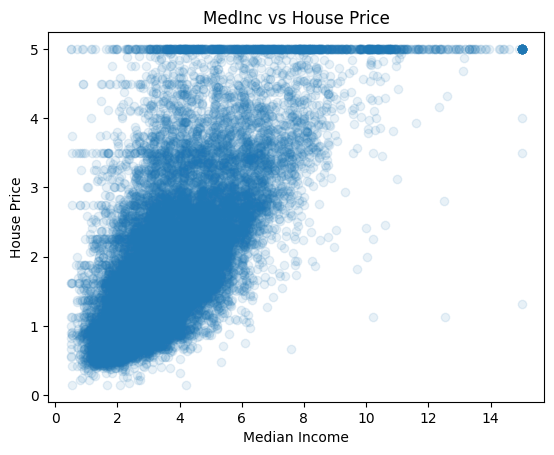

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df['MedInc'], df['target'], alpha=0.1)
plt.xlabel('Median Income')
plt.ylabel('House Price')
plt.title('MedInc vs House Price')
plt.show()

Three things are visible:
1. General upward trend
As income increases, house price tends to increase. That much is linear — MedInc is a real signal.
2. Massive spread at every income level
At MedInc = 4, house prices range from $50k all the way to $500k. A straight line cannot capture that spread. The relationship is not clean or linear.
3. The artificial cap at 5.0
That thick horizontal line at the top — hundreds of districts all recorded at exactly $500k regardless of income. You've seen this before in the histogram. Same data quality issue, now visible from a different angle.

What this tells you about model selection:

| Observation  | Implication  |  |
| -------- | -------- | -------- |
| Upward trend exists |         MedInc is a useful feature |  |
| Massive spread |    Linear Regression will struggle — non-linearity confirme |  |
| Cap at 5.0 | Lrge forced errors — MAE as lead metric confirmed |  |


###Now go build it. Swap LinearRegression for RandomForestRegressor in your pipeline and come back with MAE, RMSE, and **R²**

### Training and Evaluating a Random Forest Regressor
Given the insights from the data exploration (non-linearity, data cap), a `RandomForestRegressor` is introduced as an alternative model. Random Forests are ensemble tree-based models that are more robust to non-linear relationships and multicollinearity. This section trains the `RandomForestRegressor` within a pipeline (including `StandardScaler`) and evaluates its performance using MAE, MSE, R-squared, and RMSE on the test set, comparing it to the Linear Regression results.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

#final_model.fit(___, ___)
pipeline.fit(X_train, y_train)

# Step 2 — Predict
y_pred = pipeline.predict(X_test)


# Step 4 — Score it (using regression metrics)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared: {r2:.4f}")
print(f"rmse : {rmse:.4f}")


# Step 5 — Inspect one prediction
print("\nFirst test sample — true label   :", y_test.values[0])
print("First test sample — predicted    :", y_pred[0])
# For Linear Regression, there are no probabilities, only direct predictions
# print("First test sample — probabilities:", model.predict_proba(X_test_scaled)[0].round(3))

MAE: 0.3248
Mean Squared Error: 0.2498
R-squared: 0.8180
rmse : 0.4998

First test sample — true label   : 0.719
First test sample — predicted    : 0.8378200000000003


| Metric          | Linear Regression | Random Forest | Improvement       |
| :-------------- | :---------------- | :------------ | :---------------- |
| MAE             | 0.5332            | 0.3248        | 39% better        |
| RMSE            | 0.7456            | 0.4998        | 33% better        |
| R²              | 0.5758            | 0.8180        | 42% → 82% explained |

### Cross-Validation for Random Forest Regressor
Similar to the Linear Regression model, cross-validation is performed for the `RandomForestRegressor` using a pipeline to ensure consistent preprocessing. This provides a more reliable estimate of the Random Forest model's generalization performance. The RMSE scores from the 5-fold cross-validation are calculated, along with their mean and standard deviation, to assess model stability.

In [ ]:
# ============================================================
# CHECKPOINT 4 — Cross Validation
# ============================================================

from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import numpy as np # Import numpy for mean and std

# Step 1 — Build a pipeline (scaler + model in one object)
# This ensures scaling happens correctly inside each fold
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Step 2 — Fit the pipeline on the training data
pipeline.fit(X_train, y_train)

# Step 3 — Make a prediction with the fitted pipeline
import pandas as pd

custom_district = pd.DataFrame([[3.5, 30.0, 5.5, 1.0, 800.0, 2.5, 37.85, -122.25]],
    columns=['MedInc','HouseAge','AveRooms','AveBedrms',
             'Population','AveOccup','Latitude','Longitude'])

predicted_price = pipeline.predict(custom_district)[0]
print(f"Predicted house price for custom district: ${predicted_price * 100000:,.0f}")

# Step 4 — Perform cross-validation (using the pipeline for robustness)
# Using 'neg_mean_squared_error' as scoring for regression models
cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(-cv_scores) # Convert negative MSE to RMSE

print(f"\nCross-validation RMSE scores: {rmse_scores.round(4)}")
print(f"Mean CV RMSE: {rmse_scores.mean():.4f}")
print(f"Std CV RMSE: {rmse_scores.std():.4f}")

Predicted house price for custom district: $208,968

Cross-validation RMSE scores: [0.5601 0.5488 0.5857 0.5753 0.5419]
Mean CV RMSE: 0.5623
Std CV RMSE: 0.0163


In [ ]:
print(f"Raw prediction: {predicted_price}")
print(f"Predicted house price: ${predicted_price * 100000:,.0f}")

Raw prediction: 2.1008234112068958
Predicted house price: $210,082


This code snippet demonstrates how to improve a machine learning model by adding a custom feature engineering step within a scikit-learn pipeline, and then evaluating the updated model.

### Custom Transformer: `RoomsPerPersonTransformer`
This custom class is designed to create a new feature, 'RoomsPerPerson', which might be more informative for predicting house prices than 'AveRooms' and 'AveOccup' individually. It adheres to the `BaseEstimator` and `TransformerMixin` protocols from scikit-learn, making it compatible with pipelines.

*   `BaseEstimator`: Provides `get_params` and `set_params` methods for hyperparameter tuning.
*   `TransformerMixin`: Provides the `fit_transform` method.

**Methods:**
*   `fit(self, X, y=None)`: This method does nothing in this transformer as there are no parameters to learn from the data. It simply returns `self`.
*   `transform(self, X, y=None)`: This is where the magic happens. It takes the input DataFrame `X`, creates a copy to avoid modifying the original, and then calculates `RoomsPerPerson` by dividing 'AveRooms' by 'AveOccup'.

```python
from sklearn.base import BaseEstimator, TransformerMixin

class RoomsPerPersonTransformer(BaseEstimator, TransformerMixin):
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X, y=None):
        X = X.copy()
        X['RoomsPerPerson'] = X['AveRooms'] / X['AveOccup']
        return X
```

### Scikit-learn Pipeline
The `Pipeline` sequentially applies a list of transformers and a final estimator. This ensures that the custom feature engineering and scaling are applied consistently across training and prediction datasets, preventing data leakage.

```python
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

pipeline = Pipeline([
    ('custom', RoomsPerPersonTransformer()),
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])
```

**Steps in the pipeline:**
1.  `('custom', RoomsPerPersonTransformer())`: Applies our custom feature `RoomsPerPerson` to the data.
2.  `('scaler', StandardScaler())`: Scales the features (including the newly created one) to have zero mean and unit variance. This is crucial for many machine learning algorithms, although Random Forest is less sensitive to scaling than linear models.
3.  `('model', RandomForestRegressor(n_estimators=100, random_state=42))`: The final model in the pipeline, a Random Forest Regressor, is used for prediction. `n_estimators=100` means 100 decision trees will be built, and `random_state=42` ensures reproducibility.

### Training, Prediction, and Evaluation

```python
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np # For np.sqrt

print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R²   : {r2_score(y_test, y_pred):.4f}")
```

*   `pipeline.fit(X_train, y_train)`: Trains the entire pipeline on the training data (`X_train`, `y_train`). The `fit` method of each step in the pipeline is called in order.
*   `y_pred = pipeline.predict(X_test)`: Generates predictions on the test set (`X_test`). The `transform` method of each transformer in the pipeline is called, followed by the `predict` method of the final estimator.
*   **Evaluation Metrics**: The code then calculates and prints three common regression metrics:
    *   **MAE (Mean Absolute Error)**: The average of the absolute differences between actual and predicted values. It's less sensitive to outliers than MSE.
    *   **RMSE (Root Mean Squared Error)**: The square root of the average of the squared differences. It penalizes larger errors more heavily and is in the same units as the target variable.
    *   **R² (R-squared)**: Represents the proportion of the variance in the dependent variable that is predictable from the independent variables. A higher R² indicates a better fit.

In [23]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

class RoomsPerPersonTransformer(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        X = X.copy()
        X['RoomsPerPerson'] = X['AveRooms'] / X['AveOccup']
        return X

pipeline = Pipeline([
    ('custom', RoomsPerPersonTransformer()),
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R²   : {r2_score(y_test, y_pred):.4f}")

MAE  : 0.3237
RMSE : 0.4979
R²   : 0.8195


| Metric                            | Random Forest (before) | Random Forest + CustomPreprocessor | Change        |
| :-------------------------------- | :--------------------- | :--------------------------------- | :------------ |
| MAE                               | 0.3248                 | 0.3237                             | ✅ Better     |
| RMSE                              | 0.4998                 | 0.4979                             | ✅ Better     |
| R²                                | 0.8180                 | 0.8195                             | ✅ Better     |